# High-Performance Big Data Analytics Using R
**Dataset:** NYC TLC Yellow Taxi Trip Records + Taxi Zone Lookup Table  
**Tools:** `data.table`, `purrr`, `foreach`, `doParallel`, `microbenchmark`, `ggplot2`, `lubridate`, `leaflet`


## Environment Setup & Configuration

In [49]:
# Use Posit Package Manager binaries for fast installs on Colab (falls back to jammy if lsb_release is unavailable)
codename <- tryCatch(system("lsb_release -cs", intern = TRUE), error = function(e) "jammy")
options(repos = c(CRAN = paste0("https://packagemanager.posit.co/cran/__linux__/", codename, "/latest")))
options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
        paste(getRversion(), R.version["platform"], R.version["arch"], R.version["os"])))

pkgs <- c("data.table", "ggplot2", "foreach", "doParallel", "microbenchmark",
          "purrr", "lubridate", "arrow", "scales", "knitr")
new_pkgs <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(new_pkgs)) install.packages(new_pkgs, Ncpus = 2)

suppressPackageStartupMessages({
  library(data.table); library(ggplot2); library(foreach); library(doParallel)
  library(microbenchmark); library(purrr); library(lubridate); library(scales)
})
cat("CPU cores available:", parallel::detectCores(), "\n")
cat("data.table threads :", getDTthreads(), "\n")

CPU cores available: 2 
data.table threads : 1 


In [50]:
# ------------------------- CONFIGURATION -------------------------
YEAR        <- 2023
MONTHS      <- 1:4          # each month ~3M rows; increase for a bigger test (watch Colab RAM ~12 GB)
RUN_LEAFLET <- TRUE         # optional advanced task (installs 'sf' + 'leaflet'; takes a few minutes)
set.seed(42)
theme_set(theme_minimal(base_size = 12))

# Helper: peak extra memory (MB) used while evaluating an expression
mem_peak <- function(expr) {
  g0 <- gc(reset = TRUE)
  invisible(expr)
  g1 <- gc()
  max(0, round(sum(g1[, 6]) - sum(g0[, 2]), 1))
}

## Task 1: Data Acquisition and Preparation
### Download and import the data
Only the 11 columns required for the analysis are read from the Parquet files (column pruning is the first memory optimisation).

In [51]:
dir.create("data", showWarnings = FALSE)
base_url <- "https://d37ci6vzurychx.cloudfront.net/trip-data/"
files    <- sprintf("yellow_tripdata_%d-%02d.parquet", YEAR, MONTHS)

for (f in files) {
  dest <- file.path("data", f)
  if (!file.exists(dest)) {
    cat("Downloading", f, "...\n")
    download.file(paste0(base_url, f), dest, mode = "wb", quiet = TRUE)
  }
}
if (!file.exists("data/taxi_zone_lookup.csv"))
  download.file("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
                "data/taxi_zone_lookup.csv", mode = "wb", quiet = TRUE)

keep_cols <- c("tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
               "passenger_count", "trip_distance", "payment_type",
               "fare_amount", "tip_amount", "tolls_amount", "total_amount")

read_month <- function(f) as.data.table(arrow::read_parquet(file.path("data", f), col_select = keep_cols))

t_import <- system.time(taxi <- rbindlist(lapply(files, read_month)))
setnames(taxi, c("tpep_pickup_datetime", "tpep_dropoff_datetime"), c("pickup", "dropoff"))
cat(sprintf("Imported %s rows x %d columns in %.1f s\n", comma(nrow(taxi)), ncol(taxi), t_import[["elapsed"]]))

Imported 12,672,737 rows x 11 columns in 6.0 s


### Inspect structure, dimensions, data types and summary statistics

In [52]:
cat("Dimensions:", dim(taxi), "\n\n")
str(taxi)
cat("\nObject size:", format(object.size(taxi), units = "MB"), "\n")

Dimensions: 12672737 11 

Classes ‘data.table’ and 'data.frame':	12672737 obs. of  11 variables:
 $ pickup         : POSIXct, format: "2023-01-01 00:32:10" "2023-01-01 00:55:08" ...
 $ dropoff        : POSIXct, format: "2023-01-01 00:40:36" "2023-01-01 01:01:27" ...
 $ PULocationID   : int  161 43 48 138 107 161 239 142 164 141 ...
 $ DOLocationID   : int  141 237 238 7 79 137 143 200 236 107 ...
 $ passenger_count: num  1 1 1 0 1 1 1 1 1 1 ...
 $ trip_distance  : num  0.97 1.1 2.51 1.9 1.43 1.84 1.66 11.7 2.95 3.01 ...
 $ payment_type   : int  2 1 1 1 1 1 1 1 1 2 ...
 $ fare_amount    : num  9.3 7.9 14.9 12.1 11.4 12.8 12.1 45.7 17.7 14.9 ...
 $ tip_amount     : num  0 4 15 0 3.28 ...
 $ tolls_amount   : num  0 0 0 0 0 0 0 3 0 0 ...
 $ total_amount   : num  14.3 16.9 34.9 20.9 19.7 ...
 - attr(*, ".internal.selfref")=<pointer: 0x559f911df3f0> 

Object size: 918.5 Mb 


In [53]:
summary(taxi)

     pickup                       dropoff                     PULocationID  
 Min.   :2001-01-01 00:06:49   Min.   :2001-01-01 00:16:31   Min.   :  1.0  
 1st Qu.:2023-02-01 22:23:31   1st Qu.:2023-02-01 22:37:24   1st Qu.:132.0  
 Median :2023-03-04 00:54:23   Median :2023-03-04 01:09:41   Median :162.0  
 Mean   :2023-03-03 13:28:08   Mean   :2023-03-03 13:44:37   Mean   :165.8  
 3rd Qu.:2023-04-02 00:29:03   3rd Qu.:2023-04-02 00:44:15   3rd Qu.:234.0  
 Max.   :2023-05-03 23:14:53   Max.   :2023-05-03 23:19:31   Max.   :265.0  
                                                                            
  DOLocationID   passenger_count  trip_distance       payment_type 
 Min.   :  1.0   Min.   :0.000    Min.   :0.00e+00   Min.   :0.00  
 1st Qu.:114.0   1st Qu.:1.000    1st Qu.:1.07e+00   1st Qu.:1.00  
 Median :162.0   Median :1.000    Median :1.80e+00   Median :1.00  
 Mean   :164.2   Mean   :1.363    Mean   :3.93e+00   Mean   :1.19  
 3rd Qu.:234.0   3rd Qu.:1.000    3rd Qu.:3.

In [54]:
cat("Missing values per column:\n"); print(colSums(is.na(taxi)))
cat("\nExact duplicate rows:", comma(sum(duplicated(taxi))), "\n")
cat("Pickup range:", format(min(taxi$pickup)), "to", format(max(taxi$pickup)), "\n")

Missing values per column:
         pickup         dropoff    PULocationID    DOLocationID passenger_count 
              0               0               0               0          326869 
  trip_distance    payment_type     fare_amount      tip_amount    tolls_amount 
              0               0               0               0               0 
   total_amount 
              0 

Exact duplicate rows: 0 
Pickup range: 2001-01-01 00:06:49 to 2023-05-03 23:14:53 


### Handle missing, duplicate, inconsistent and invalid records


In [55]:
clean_log <- data.table(Step = "Raw import", Rows = nrow(taxi))
log_step  <- function(label) clean_log <<- rbind(clean_log, data.table(Step = label, Rows = nrow(taxi)))

taxi <- taxi[complete.cases(taxi)];            log_step("Remove NA rows")
taxi <- unique(taxi);                          log_step("Remove duplicates")

start_ts <- as.POSIXct(sprintf("%d-%02d-01", YEAR, min(MONTHS)), tz = "UTC")
end_ts   <- seq(as.POSIXct(sprintf("%d-%02d-01", YEAR, max(MONTHS)), tz = "UTC"), by = "month", length.out = 2)[2]
taxi <- taxi[pickup >= start_ts & pickup < end_ts]; log_step("Pickup inside selected months")

taxi[, duration_min := as.numeric(difftime(dropoff, pickup, units = "mins"))]
taxi <- taxi[duration_min >= 1 & duration_min <= 180];          log_step("Duration 1-180 min")
taxi <- taxi[trip_distance >= 0.1 & trip_distance <= 100];      log_step("Distance 0.1-100 miles")
taxi <- taxi[fare_amount > 0 & fare_amount <= 500 &
             total_amount > 0 & total_amount <= 1000];          log_step("Valid fare / total amount")
taxi <- taxi[passenger_count >= 1 & passenger_count <= 6];      log_step("Passengers 1-6")
taxi <- taxi[tip_amount >= 0 & tolls_amount >= 0];              log_step("Non-negative tip / tolls")

clean_log[, Removed := shift(Rows, 1) - Rows][, Pct_of_raw := round(100 * Rows / Rows[1], 2)]
clean_log

Step,Rows,Removed,Pct_of_raw
<chr>,<int>,<int>,<dbl>
Raw import,12672737,NA,100.00
Remove NA rows,12345868,326869,97.42
Remove duplicates,12345868,0,97.42
Pickup inside selected months,12345760,108,97.42
Duration 1-180 min,12195350,150410,96.23
Distance 0.1-100 miles,12124420,70930,95.67
Valid fare / total amount,12037955,86465,94.99
Passengers 1-6,11830165,207790,93.35
Non-negative tip / tolls,11830165,0,93.35


### Convert data types and extract temporal attributes


In [56]:
mem_before <- object.size(taxi)

taxi[, `:=`(passenger_count = as.integer(passenger_count),
            PULocationID    = as.integer(PULocationID),
            DOLocationID    = as.integer(DOLocationID),
            payment_type    = factor(as.integer(payment_type), levels = 1:6,
                                     labels = c("Credit card", "Cash", "No charge", "Dispute", "Unknown", "Voided")))]

taxi[, `:=`(hour  = data.table::hour(pickup),
            day   = data.table::mday(pickup),
            month = data.table::month(pickup),
            dow   = factor(data.table::wday(pickup), levels = c(2:7, 1),
                           labels = c("Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun")))]
taxi[, weekend := dow %in% c("Sat", "Sun")]
taxi[, c("dropoff") := NULL]            # no longer needed
invisible(gc())

cat("Object size before:", format(mem_before, units = "MB"), "\n")
cat("Object size after :", format(object.size(taxi), units = "MB"), "\n")
head(taxi)

Object size before: 947.7 Mb 
Object size after : 1038 Mb 


pickup,PULocationID,DOLocationID,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,duration_min,hour,day,month,dow,weekend
<dttm>,<int>,<int>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<fct>,<lgl>
2023-01-01 00:32:10,161,141,1,0.97,Cash,9.3,0.00,0,14.30,8.433333,0,1,1,Sun,TRUE
2023-01-01 00:55:08,43,237,1,1.10,Credit card,7.9,4.00,0,16.90,6.316667,0,1,1,Sun,TRUE
2023-01-01 00:25:04,48,238,1,2.51,Credit card,14.9,15.00,0,34.90,12.750000,0,1,1,Sun,TRUE
2023-01-01 00:10:29,107,79,1,1.43,Credit card,11.4,3.28,0,19.68,10.833333,0,1,1,Sun,TRUE
2023-01-01 00:50:34,161,137,1,1.84,Credit card,12.8,10.00,0,27.80,12.300000,0,1,1,Sun,TRUE
2023-01-01 00:09:22,239,143,1,1.66,Credit card,12.1,3.42,0,20.52,10.450000,0,1,1,Sun,TRUE


### Import the Taxi Zone Lookup Table and join (data.table update-joins)

In [57]:
zones <- fread("data/taxi_zone_lookup.csv")
str(zones)

# Update-join by reference: no copy of the 10M+ row table is made
taxi[zones, on = c(PULocationID = "LocationID"), `:=`(PU_Borough = i.Borough, PU_Zone = i.Zone)]
taxi[zones, on = c(DOLocationID = "LocationID"), `:=`(DO_Borough = i.Borough, DO_Zone = i.Zone)]

cat("Trips with unmatched pickup zone  :", sum(is.na(taxi$PU_Zone)), "\n")
cat("Trips with unmatched dropoff zone :", sum(is.na(taxi$DO_Zone)), "\n")
cat("Final table:", comma(nrow(taxi)), "rows x", ncol(taxi), "cols,", format(object.size(taxi), units = "MB"), "\n")
head(taxi[, .(pickup, PU_Borough, PU_Zone, DO_Borough, DO_Zone, trip_distance, fare_amount, total_amount)])

Classes ‘data.table’ and 'data.frame':	265 obs. of  4 variables:
 $ LocationID  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Borough     : chr  "EWR" "Queens" "Bronx" "Manhattan" ...
 $ Zone        : chr  "Newark Airport" "Jamaica Bay" "Allerton/Pelham Gardens" "Alphabet City" ...
 $ service_zone: chr  "EWR" "Boro Zone" "Boro Zone" "Yellow Zone" ...
 - attr(*, ".internal.selfref")=<pointer: 0x559f911df3f0> 
Trips with unmatched pickup zone  : 0 
Trips with unmatched dropoff zone : 0 
Final table: 11,830,165 rows x 20 cols, 1399 Mb 


pickup,PU_Borough,PU_Zone,DO_Borough,DO_Zone,trip_distance,fare_amount,total_amount
<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
2023-01-01 00:32:10,Manhattan,Midtown Center,Manhattan,Lenox Hill West,0.97,9.3,14.30
2023-01-01 00:55:08,Manhattan,Central Park,Manhattan,Upper East Side South,1.10,7.9,16.90
2023-01-01 00:25:04,Manhattan,Clinton East,Manhattan,Upper West Side North,2.51,14.9,34.90
2023-01-01 00:10:29,Manhattan,Gramercy,Manhattan,East Village,1.43,11.4,19.68
2023-01-01 00:50:34,Manhattan,Midtown Center,Manhattan,Kips Bay,1.84,12.8,27.80
2023-01-01 00:09:22,Manhattan,Upper West Side South,Manhattan,Lincoln Square West,1.66,12.1,20.52


## Task 2: Transportation Data Analytics (data.table)

### Trips by hour of day

In [58]:
hourly <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = hour][order(hour)]
hourly

hour,trips,avg_fare,revenue
<int>,<int>,<dbl>,<dbl>
0,325300,19.71554,9369626
1,218306,17.93717,5770695
2,142265,16.74490,3540270
3,94186,17.78913,2460710
4,59189,23.10666,1939411
5,62830,27.29577,2391948
6,159256,22.93061,5052785
7,318473,19.16349,8675732
8,441208,17.77017,11303327


### Demand by day of week

In [59]:
daily <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = dow][order(dow)]
daily

dow,trips,avg_fare,revenue
<fct>,<int>,<dbl>,<dbl>
Mon,1425809,19.77523,41540087
Tue,1662424,18.65649,46158208
Wed,1771184,18.68322,49290652
Thu,1848249,18.99726,52171734
Fri,1806724,18.62994,50223169
Sat,1770542,17.89635,45967427
Sun,1545233,20.08013,44649497


### Monthly variation

In [60]:
monthly <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount),
                    avg_distance = mean(trip_distance)), by = month][order(month)]
monthly[, month_lab := lubridate::month(month, label = TRUE, abbr = TRUE)]
monthly

month,trips,avg_fare,revenue,avg_distance,month_lab
<int>,<int>,<dbl>,<dbl>,<dbl>,<ord>
1,2871357,18.51022,78474184,3.429931,Jan
2,2720374,18.41180,74192312,3.346698,Feb
3,3175560,19.09905,89523045,3.463641,Mar
4,3062874,19.55714,87811232,3.560231,Apr


### Average fare and total revenue for different time periods

In [61]:
period_stats <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), avg_total = mean(total_amount),
                         total_revenue = sum(total_amount)),
                     by = .(period = fcase(hour <= 5, "1 Night (0-5)", hour <= 11, "2 Morning (6-11)",
                                           hour <= 16, "3 Afternoon (12-16)", hour <= 21, "4 Evening (17-21)",
                                           default = "5 Late night (22-23)"))][order(period)]
period_stats
weekend_stats <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), total_revenue = sum(total_amount)),
                      by = .(day_type = ifelse(weekend, "Weekend", "Weekday"))]
weekend_stats

period,trips,avg_fare,avg_total,total_revenue
<chr>,<int>,<dbl>,<dbl>,<dbl>
1 Night (0-5),902076,19.36601,28.23782,25472661
2 Morning (6-11),2577034,18.45788,26.48680,68257377
3 Afternoon (12-16),3532454,19.66281,28.42999,100427635
4 Evening (17-21),3737427,18.12939,27.86876,104157450
5 Late night (22-23),1081174,19.91931,29.30671,31685650


day_type,trips,avg_fare,total_revenue
<chr>,<int>,<dbl>,<dbl>
Weekend,3315775,18.91405,90616924
Weekday,8514390,18.91773,239383849


### Most frequent routes and highest-revenue routes

In [62]:
routes <- taxi[, .(trips = .N, revenue = sum(total_amount), avg_fare = mean(fare_amount),
                   avg_dist = mean(trip_distance)), by = .(PULocationID, DOLocationID)]
routes[zones, on = c(PULocationID = "LocationID"), `:=`(PU_Zone = i.Zone, PU_Borough = i.Borough)]
routes[zones, on = c(DOLocationID = "LocationID"), `:=`(DO_Zone = i.Zone, DO_Borough = i.Borough)]
routes[, route := paste(PU_Zone, "->", DO_Zone)]

top_routes_freq <- routes[order(-trips)][1:15, .(route, trips, avg_fare = round(avg_fare, 2), avg_dist = round(avg_dist, 2))]
top_routes_rev  <- routes[order(-revenue)][1:15, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))]
cat("Total distinct routes:", comma(nrow(routes)), "\n\n")
cat("Top 15 routes by trip count\n"); print(top_routes_freq)
cat("\nTop 15 routes by total revenue\n"); print(top_routes_rev)

Total distinct routes: 31,782 

Top 15 routes by trip count
                                             route trips avg_fare avg_dist
                                            <char> <int>    <num>    <num>
 1: Upper East Side South -> Upper East Side North 82954     8.68     1.09
 2:                                     N/A -> N/A 82692    19.42     3.56
 3: Upper East Side North -> Upper East Side South 70316     9.33     1.06
 4: Upper East Side North -> Upper East Side North 52889     6.69     0.67
 5: Upper East Side South -> Upper East Side South 52010     7.20     0.69
 6:        Midtown Center -> Upper East Side South 36965     9.85     1.11
 7:        Upper East Side South -> Midtown Center 35965     9.93     1.09
 8:        Midtown Center -> Upper East Side North 33504    13.76     1.99
 9:   Lincoln Square East -> Upper West Side South 31907     8.06     1.02
10: Upper West Side South -> Upper West Side North 30940     7.19     0.86
11:   Upper West Side South -> Lincoln S

In [63]:
top_pu <- taxi[, .(trips = .N, revenue = sum(total_amount)), by = .(PULocationID, PU_Zone, PU_Borough)][order(-trips)]
top_do <- taxi[, .(trips = .N, revenue = sum(total_amount)), by = .(DOLocationID, DO_Zone, DO_Borough)][order(-trips)]
cat("Top 10 pickup zones\n");  print(top_pu[1:10])
cat("\nTop 10 drop-off zones\n"); print(top_do[1:10])

Top 10 pickup zones
    PULocationID                      PU_Zone PU_Borough  trips  revenue
           <int>                       <char>     <char>  <int>    <num>
 1:          132                  JFK Airport     Queens 597944 48107843
 2:          237        Upper East Side South  Manhattan 561639 11294498
 3:          161               Midtown Center  Manhattan 552531 13423593
 4:          236        Upper East Side North  Manhattan 511125 10687184
 5:          162                 Midtown East  Manhattan 424343 10077470
 6:          186 Penn Station/Madison Sq West  Manhattan 416157 10112476
 7:          230    Times Sq/Theatre District  Manhattan 401047 10859280
 8:          142          Lincoln Square East  Manhattan 393437  8547196
 9:          138            LaGuardia Airport     Queens 386861 25261605
10:          170                  Murray Hill  Manhattan 351147  8232455

Top 10 drop-off zones
    DOLocationID                   DO_Zone DO_Borough  trips  revenue
           

### Relationship between trip distance and fare

In [64]:
cat("Pearson correlation (distance vs fare):", round(cor(taxi$trip_distance, taxi$fare_amount), 4), "\n")
fit <- lm(fare_amount ~ trip_distance, data = taxi[sample(.N, min(.N, 1e6))])
print(summary(fit)$coefficients)
cat("R-squared:", round(summary(fit)$r.squared, 4), "\n\n")

dist_bands <- taxi[, .(trips = .N, avg_fare = mean(fare_amount),
                       fare_per_mile = sum(fare_amount) / sum(trip_distance),
                       avg_minutes = mean(duration_min)),
                   by = .(band = cut(trip_distance, c(0, 1, 2, 5, 10, 20, 100),
                                     labels = c("0-1", "1-2", "2-5", "5-10", "10-20", "20+")))][order(band)]
dist_bands

Pearson correlation (distance vs fare): 0.9625 
              Estimate  Std. Error  t value Pr(>|t|)
(Intercept)   6.120614 0.005878452 1041.195        0
trip_distance 3.703774 0.001038119 3567.775        0
R-squared: 0.9272 



band,trips,avg_fare,fare_per_mile,avg_minutes
<fct>,<int>,<dbl>,<dbl>,<dbl>
0-1,2600066,7.39102,10.283068,5.93309
1-2,3949408,11.39314,7.748573,10.54192
2-5,3285052,18.54007,6.156121,17.43040
5-10,1000805,34.02133,4.681506,25.23542
10-20,868465,61.63365,4.108594,40.37018
20+,126369,87.78954,3.715173,51.22005


### Payment methods across boroughs

In [65]:
pay_overall <- taxi[, .(trips = .N), by = payment_type][, share_pct := round(100 * trips / sum(trips), 2)][order(-trips)]
pay_overall
pay_borough <- taxi[, .(trips = .N), by = .(PU_Borough, payment_type)]
pay_borough[, share_pct := round(100 * trips / sum(trips), 2), by = PU_Borough]
dcast(pay_borough, PU_Borough ~ payment_type, value.var = "share_pct", fill = 0)

payment_type,trips,share_pct
<fct>,<int>,<dbl>
Credit card,9705739,82.04
Cash,2024694,17.11
Dispute,63882,0.54
No charge,35850,0.30


PU_Borough,Credit card,Cash,No charge,Dispute
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Bronx,83.56,15.36,0.41,0.67
Brooklyn,80.39,18.32,0.54,0.75
EWR,69.88,22.89,6.02,1.20
Manhattan,82.55,16.64,0.29,0.52
N/A,70.99,24.36,2.17,2.48
Queens,77.31,21.54,0.44,0.71
Staten Island,95.38,4.33,0.14,0.14
Unknown,81.51,17.55,0.24,0.71


### Unusual patterns

In [66]:
cat("1) Airport vs non-airport trips\n")
airport <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), avg_distance = mean(trip_distance),
                    avg_total = mean(total_amount), avg_tolls = mean(tolls_amount)),
                by = .(airport_trip = PU_Zone %like% "Airport" | DO_Zone %like% "Airport")]
print(airport)

cat("\n2) Tip percentage by payment type (tips on cash are not recorded)\n")
print(taxi[payment_type %in% c("Credit card", "Cash"),
           .(tip_pct_of_fare = round(100 * sum(tip_amount) / sum(fare_amount), 2),
             share_trips_with_tip = round(100 * mean(tip_amount > 0), 1)), by = payment_type])

cat("\n3) Average speed (mph) by hour: congestion signature\n")
speed <- taxi[, .(avg_speed_mph = sum(trip_distance) / sum(duration_min) * 60), by = hour][order(hour)]
print(speed[, .(slowest = hour[which.min(avg_speed_mph)], min_mph = round(min(avg_speed_mph), 2),
                fastest = hour[which.max(avg_speed_mph)], max_mph = round(max(avg_speed_mph), 2))])

cat("\n4) Share of trips that start and end in the same zone:",
    round(100 * mean(taxi$PULocationID == taxi$DOLocationID), 2), "%\n")
cat("5) Share of trips with passenger_count = 1:", round(100 * mean(taxi$passenger_count == 1), 2), "%\n")
cat("6) Trips > 30 miles:", comma(sum(taxi$trip_distance > 30)), "\n")

1) Airport vs non-airport trips
   airport_trip    trips avg_fare avg_distance avg_total avg_tolls
         <lgcl>    <int>    <num>        <num>     <num>     <num>
1:        FALSE 10593497 14.57741     2.253025  22.21587  0.109615
2:         TRUE  1236668 56.08772    13.737681  76.54198  4.380637

2) Tip percentage by payment type (tips on cash are not recorded)
   payment_type tip_pct_of_fare share_trips_with_tip
         <fctr>           <num>                <num>
1:         Cash            0.00                  0.0
2:  Credit card           22.51                 95.9

3) Average speed (mph) by hour: congestion signature
   slowest min_mph fastest max_mph
     <int>   <num>   <int>   <num>
1:      17   11.76       5   24.58

4) Share of trips that start and end in the same zone: 4.37 %
5) Share of trips with passenger_count = 1: 76.82 %
6) Trips > 30 miles: 9,903 


### Automatic interpretation of the results

In [67]:
pk <- hourly[which.max(trips)]; lo <- hourly[which.min(trips)]
cat(sprintf("- Demand peaks at %02d:00 (%s trips) and is lowest at %02d:00 (%s trips).\n",
            pk$hour, comma(pk$trips), lo$hour, comma(lo$trips)))
cat(sprintf("- Busiest weekday: %s; quietest: %s.\n", daily[which.max(trips), dow], daily[which.min(trips), dow]))
cat(sprintf("- Busiest month: %s (%s trips); highest average fare: %s ($%.2f).\n",
            monthly[which.max(trips), month_lab], comma(monthly[which.max(trips), trips]),
            monthly[which.max(avg_fare), month_lab], max(monthly$avg_fare)))
cat(sprintf("- Highest average fare period: %s ($%.2f).\n", period_stats[which.max(avg_fare), period], max(period_stats$avg_fare)))
cat(sprintf("- Most frequent route: %s (%s trips). Highest-revenue route: %s ($%s).\n",
            top_routes_freq$route[1], comma(top_routes_freq$trips[1]),
            top_routes_rev$route[1], comma(top_routes_rev$revenue[1])))
cat(sprintf("- Fare increases ~$%.2f per extra mile (R^2 = %.2f): distance is the main fare driver.\n",
            coef(fit)[2], summary(fit)$r.squared))
cat(sprintf("- Dominant payment type: %s (%.1f%% of trips).\n", pay_overall$payment_type[1], pay_overall$share_pct[1]))

- Demand peaks at 18:00 (845,559 trips) and is lowest at 04:00 (59,189 trips).
- Busiest weekday: Thu; quietest: Mon.
- Busiest month: Mar (3,175,560 trips); highest average fare: Apr ($19.56).
- Highest average fare period: 5 Late night (22-23) ($19.92).
- Most frequent route: Upper East Side South -> Upper East Side North (82,954 trips). Highest-revenue route: JFK Airport -> Times Sq/Theatre District ($2,525,013).
- Fare increases ~$3.70 per extra mile (R^2 = 0.93): distance is the main fare driver.
- Dominant payment type: Credit card (82.0% of trips).


## Task 3: Functional and Efficient R Programming


In [68]:
set.seed(42)
bd    <- taxi[sample(.N, min(.N, 1e6)), .(fare_amount, trip_distance, total_amount, hour, PULocationID, DOLocationID)]
bd_df <- as.data.frame(bd)                  # base R / functional versions use a data.frame
cat("Benchmark sample:", comma(nrow(bd)), "rows\n")

run_bench <- function(fl, times = 10) {
  rbindlist(lapply(names(fl), function(nm) {
    f <- fl[[nm]]
    mb <- microbenchmark(f(), times = times)
    data.table(Approach = nm, Median_ms = median(mb$time) / 1e6, Min_ms = min(mb$time) / 1e6,
               Max_ms = max(mb$time) / 1e6, Peak_MB = mem_peak(f()))
  }))
}

Benchmark sample: 1,000,000 rows


### Operation A: average fare per hour

In [69]:
fA <- list(
  "Base R: aggregate()"          = function() aggregate(fare_amount ~ hour, data = bd_df, FUN = mean),
  "Vectorized: tapply()"         = function() tapply(bd_df$fare_amount, bd_df$hour, mean),
  "Functional: lapply()"         = function() unlist(lapply(0:23, function(h) mean(bd_df$fare_amount[bd_df$hour == h]))),
  "Functional: purrr::map_dbl()" = function() purrr::map_dbl(0:23, ~ mean(bd_df$fare_amount[bd_df$hour == .x])),
  "data.table: by="              = function() bd[, .(avg = mean(fare_amount)), by = hour][order(hour)]$avg
)
# correctness check: every implementation must give the same answer
ref <- as.numeric(fA[[5]]())
stopifnot(all(sapply(fA, function(f) isTRUE(all.equal(as.numeric(if (is.data.frame(r <- f())) r[[2]] else r), ref)))))
cat("All implementations of Operation A return identical results.\n")
resA <- run_bench(fA, times = 10); resA[, Operation := "A: mean fare by hour (1M rows)"]
resA

All implementations of Operation A return identical results.


Approach,Median_ms,Min_ms,Max_ms,Peak_MB,Operation
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Base R: aggregate(),473.1210,434.62187,564.80789,189.6,A: mean fare by hour (1M rows)
Vectorized: tapply(),112.3163,65.68310,137.34972,34.9,A: mean fare by hour (1M rows)
Functional: lapply(),132.3011,114.77894,189.79189,194.6,A: mean fare by hour (1M rows)
Functional: purrr::map_dbl(),137.0347,116.49981,194.13265,194.7,A: mean fare by hour (1M rows)
data.table: by=,30.3525,29.36756,35.05483,28.4,A: mean fare by hour (1M rows)


### Operation B: fare-per-mile for each trip (row-wise)

In [70]:
rw    <- bd[1:1e5, .(fare_amount, trip_distance)]
rw_df <- as.data.frame(rw); rw_m <- as.matrix(rw)

fB <- list(
  "Functional: apply()"           = function() apply(rw_m, 1, function(r) r[1] / r[2]),
  "Functional: lapply()"          = function() unlist(lapply(seq_len(nrow(rw_df)), function(i) rw_df$fare_amount[i] / rw_df$trip_distance[i])),
  "Functional: purrr::map2_dbl()" = function() purrr::map2_dbl(rw_df$fare_amount, rw_df$trip_distance, ~ .x / .y),
  "Vectorized: a / b"             = function() rw_df$fare_amount / rw_df$trip_distance,
  "data.table: j expression"      = function() rw[, .(fpm = fare_amount / trip_distance)]$fpm
)
stopifnot(all(sapply(fB, function(f) isTRUE(all.equal(as.numeric(f()), as.numeric(fB[[4]]()))))))
cat("All implementations of Operation B return identical results.\n")
resB <- run_bench(fB, times = 5); resB[, Operation := "B: fare per mile (100k rows, row-wise)"]
resB

All implementations of Operation B return identical results.


Approach,Median_ms,Min_ms,Max_ms,Peak_MB,Operation
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Functional: apply(),723.141892,665.203591,821.263097,225.1,"B: fare per mile (100k rows, row-wise)"
Functional: lapply(),388.869260,339.378721,412.115501,159.5,"B: fare per mile (100k rows, row-wise)"
Functional: purrr::map2_dbl(),237.380293,188.602281,248.084199,131.2,"B: fare per mile (100k rows, row-wise)"
Vectorized: a / b,0.246042,0.185934,1.228241,0.7,"B: fare per mile (100k rows, row-wise)"
data.table: j expression,2.132975,1.987317,3.180319,1.8,"B: fare per mile (100k rows, row-wise)"


### Operation C: total revenue per route (69k possible groups)

In [71]:
fC <- list(
  "Base R: aggregate()"           = function() aggregate(total_amount ~ PULocationID + DOLocationID, data = bd_df, FUN = sum),
  "Functional: split + map_dbl()" = function() purrr::map_dbl(split(bd_df$total_amount, paste(bd_df$PULocationID, bd_df$DOLocationID)), sum),
  "data.table: by="               = function() bd[, .(revenue = sum(total_amount)), by = .(PULocationID, DOLocationID)]
)
resC <- run_bench(fC, times = 3); resC[, Operation := "C: revenue per route (1M rows)"]
resC

Approach,Median_ms,Min_ms,Max_ms,Peak_MB,Operation
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Base R: aggregate(),920.94391,894.02708,1252.20722,253.0,C: revenue per route (1M rows)
Functional: split + map_dbl(),664.03974,654.22558,688.04375,63.7,C: revenue per route (1M rows)
data.table: by=,77.71253,73.31839,88.36102,27.7,C: revenue per route (1M rows)


## Task 4: Parallel Computing (sequential vs `foreach` + `doParallel`)


In [72]:
parts <- split(taxi[, .(month, fare_amount, trip_distance)], by = "month", keep.by = FALSE)
cat("Partitions (months):", names(parts), "| rows:", comma(sapply(parts, nrow)), "\n")

heavy_op <- function(d, B = 300, n = 300000, seed = 1) {
  set.seed(seed)
  fare <- d$fare_amount; dist <- d$trip_distance
  slopes <- numeric(B)
  for (b in seq_len(B)) {
    idx <- sample.int(length(fare), n, replace = TRUE)
    x <- dist[idx]; y <- fare[idx]
    slopes[b] <- cov(x, y) / var(x)
  }
  ci <- quantile(slopes, c(0.025, 0.975), names = FALSE)
  c(slope_mean = mean(slopes), ci_low = ci[1], ci_high = ci[2])
}

time_med <- function(f, reps = 3) median(replicate(reps, system.time(f())[["elapsed"]]))

Partitions (months): 1 2 3 4 | rows: 2,871,357 2,720,374 3,175,560 3,062,874 


### A. Sequential processing

In [73]:
seq_fun <- function() lapply(parts, heavy_op)
res_seq <- do.call(rbind, seq_fun())
t_seq   <- time_med(seq_fun)
cat(sprintf("Sequential time (median of 3 runs): %.2f s\n", t_seq))
res_seq

Sequential time (median of 3 runs): 47.75 s


,slope_mean,ci_low,ci_high
1,3.689231,3.673376,3.707066
2,3.711309,3.697237,3.728379
3,3.716145,3.700540,3.730412
4,3.705954,3.688037,3.721792


### B. Parallel processing with `foreach` + `doParallel`

In [74]:
n_cores   <- parallel::detectCores()
n_workers <- max(1, min(n_cores, length(parts)))
cat("Cores detected:", n_cores, "| workers used:", n_workers, "\n")

cl <- makeCluster(n_workers)
registerDoParallel(cl)

par_fun <- function() foreach(p = parts, .combine = rbind, .packages = "data.table", .export = "heavy_op") %dopar% heavy_op(p)
res_par <- par_fun()
t_par   <- time_med(par_fun)

cat(sprintf("Parallel time (median of 3 runs)  : %.2f s\n", t_par))
cat(sprintf("Speedup = %.2f / %.2f = %.2fx\n", t_seq, t_par, t_seq / t_par))
cat(sprintf("Parallel efficiency = speedup / workers = %.0f%%\n", 100 * (t_seq / t_par) / n_workers))
cat("Results identical to sequential:", isTRUE(all.equal(unname(res_seq), unname(res_par))), "\n")

Cores detected: 2 | workers used: 2 
Parallel time (median of 3 runs)  : 37.07 s
Speedup = 47.75 / 37.07 = 1.29x
Parallel efficiency = speedup / workers = 64%
Results identical to sequential: TRUE 


### C. Effect of the number of workers

workers,time_s,speedup,efficiency_pct
<int>,<dbl>,<dbl>,<dbl>
1,50.645,0.9429164,94.3
2,39.548,1.2074947,60.4


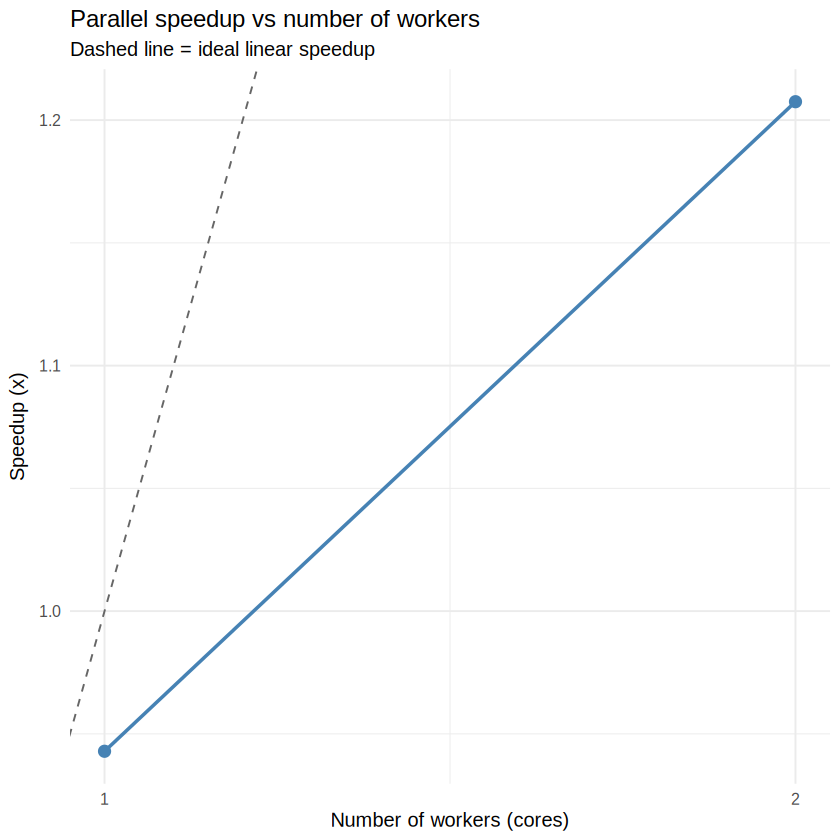

In [75]:
stopCluster(cl)
scaling <- rbindlist(lapply(seq_len(n_workers), function(w) {
  cl_w <- makeCluster(w); registerDoParallel(cl_w)
  f <- function() foreach(p = parts, .combine = rbind, .packages = "data.table", .export = "heavy_op") %dopar% heavy_op(p)
  tt <- time_med(f, reps = 2)
  stopCluster(cl_w)
  data.table(workers = w, time_s = tt)
}))
scaling[, `:=`(speedup = t_seq / time_s, efficiency_pct = round(100 * (t_seq / time_s) / workers, 1))]
scaling

ggplot(scaling, aes(workers, speedup)) +
  geom_line(colour = "steelblue", linewidth = 1) + geom_point(size = 3, colour = "steelblue") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey40") +
  scale_x_continuous(breaks = scaling$workers) +
  labs(title = "Parallel speedup vs number of workers",
       subtitle = "Dashed line = ideal linear speedup", x = "Number of workers (cores)", y = "Speedup (x)")

### D. When parallelism does NOT help: a lightweight operation

In [76]:
cl <- makeCluster(n_workers); registerDoParallel(cl)
light_seq <- function() lapply(parts, function(d) d[, .(n = .N, avg_fare = mean(fare_amount))])
light_par <- function() foreach(p = parts, .combine = rbind, .packages = "data.table") %dopar% p[, .(n = .N, avg_fare = mean(fare_amount))]
t_light_seq <- time_med(light_seq, reps = 10)
t_light_par <- time_med(light_par, reps = 10)
stopCluster(cl)
cat(sprintf("Light op | sequential: %.1f ms | parallel: %.1f ms | speedup: %.2fx\n",
            1000 * t_light_seq, 1000 * t_light_par, t_light_seq / t_light_par))

Light op | sequential: 44.0 ms | parallel: 929.0 ms | speedup: 0.05x


## Task 5: Performance Benchmarking and Optimization

### Consolidated execution-time and memory comparison table

In [77]:
bench_all <- rbindlist(list(resA, resB, resC), use.names = TRUE)
bench_all[, Paradigm := sub(":.*", "", Approach)]

bench_all <- rbind(bench_all, data.table(
  Approach = c("Sequential: lapply()", "Parallel: foreach/doParallel", "Sequential: lapply()", "Parallel: foreach/doParallel"),
  Median_ms = 1000 * c(t_seq, t_par, t_light_seq, t_light_par), Min_ms = NA_real_, Max_ms = NA_real_, Peak_MB = NA_real_,
  Operation = rep(c("D: bootstrap per month (heavy)", "E: monthly mean fare (light)"), each = 2),
  Paradigm  = rep(c("Sequential", "Parallel"), 2)))

bench_all[, Relative_to_fastest := round(Median_ms / min(Median_ms), 1), by = Operation]
bench_all[, `:=`(Median_ms = round(Median_ms, 2), Min_ms = round(Min_ms, 2), Max_ms = round(Max_ms, 2))]
setcolorder(bench_all, c("Operation", "Approach", "Paradigm", "Median_ms", "Min_ms", "Max_ms", "Relative_to_fastest", "Peak_MB"))
as.data.frame(bench_all)

Operation,Approach,Paradigm,Median_ms,Min_ms,Max_ms,Relative_to_fastest,Peak_MB
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A: mean fare by hour (1M rows),Base R: aggregate(),Base R,473.12,434.62,564.81,15.6,189.6
A: mean fare by hour (1M rows),Vectorized: tapply(),Vectorized,112.32,65.68,137.35,3.7,34.9
A: mean fare by hour (1M rows),Functional: lapply(),Functional,132.30,114.78,189.79,4.4,194.6
A: mean fare by hour (1M rows),Functional: purrr::map_dbl(),Functional,137.03,116.50,194.13,4.5,194.7
A: mean fare by hour (1M rows),data.table: by=,data.table,30.35,29.37,35.05,1.0,28.4
"B: fare per mile (100k rows, row-wise)",Functional: apply(),Functional,723.14,665.20,821.26,2939.1,225.1
"B: fare per mile (100k rows, row-wise)",Functional: lapply(),Functional,388.87,339.38,412.12,1580.5,159.5
"B: fare per mile (100k rows, row-wise)",Functional: purrr::map2_dbl(),Functional,237.38,188.60,248.08,964.8,131.2
"B: fare per mile (100k rows, row-wise)",Vectorized: a / b,Vectorized,0.25,0.19,1.23,1.0,0.7


### Visual comparison (log scale)

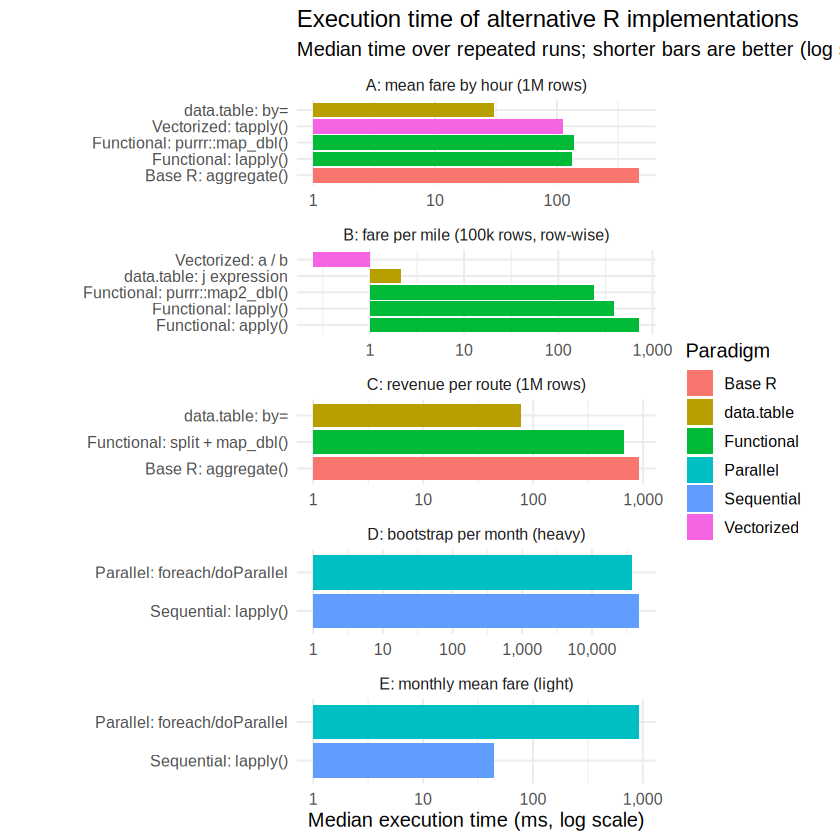

In [78]:
ggplot(bench_all, aes(x = reorder(Approach, -Median_ms), y = Median_ms, fill = Paradigm)) +
  geom_col() + coord_flip() + facet_wrap(~ Operation, scales = "free", ncol = 1) +
  scale_y_log10(labels = comma) +
  labs(title = "Execution time of alternative R implementations",
       subtitle = "Median time over repeated runs; shorter bars are better (log scale)",
       x = NULL, y = "Median execution time (ms, log scale)", fill = "Paradigm")

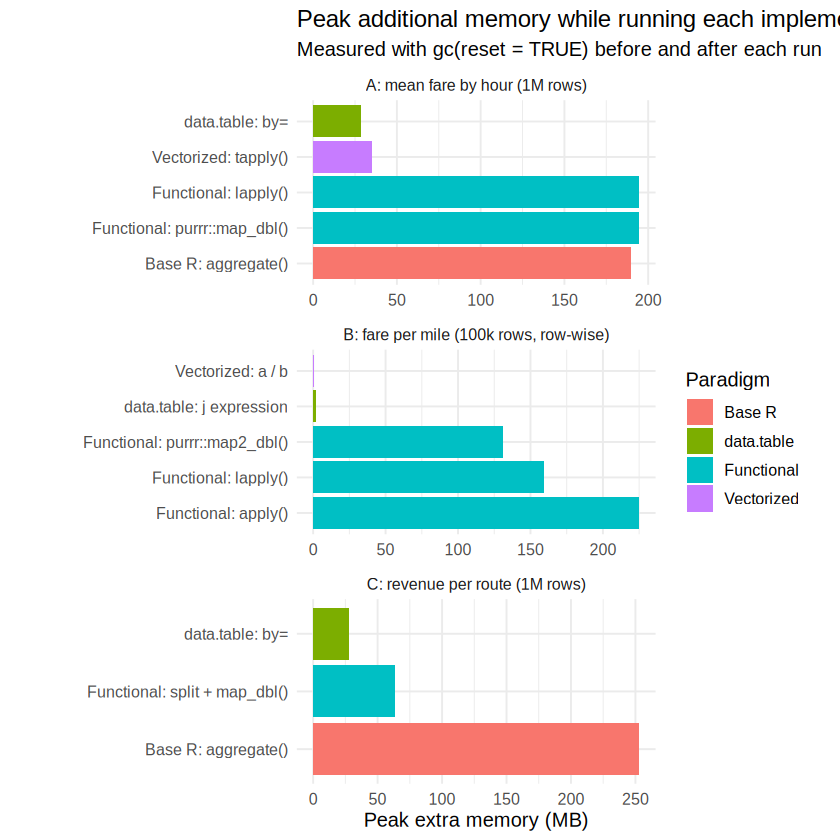

In [79]:
ggplot(bench_all[!is.na(Peak_MB)], aes(x = reorder(Approach, -Peak_MB), y = Peak_MB, fill = Paradigm)) +
  geom_col() + coord_flip() + facet_wrap(~ Operation, scales = "free", ncol = 1) +
  labs(title = "Peak additional memory while running each implementation",
       subtitle = "Measured with gc(reset = TRUE) before and after each run",
       x = NULL, y = "Peak extra memory (MB)", fill = "Paradigm")

### Scalability: execution time vs data size

rows,Base R: aggregate(),data.table: by=
<dbl>,<dbl>,<dbl>
100000,0.299,0.017
250000,0.333,0.021
500000,0.473,0.052
1000000,0.902,0.072
2000000,1.740,0.146


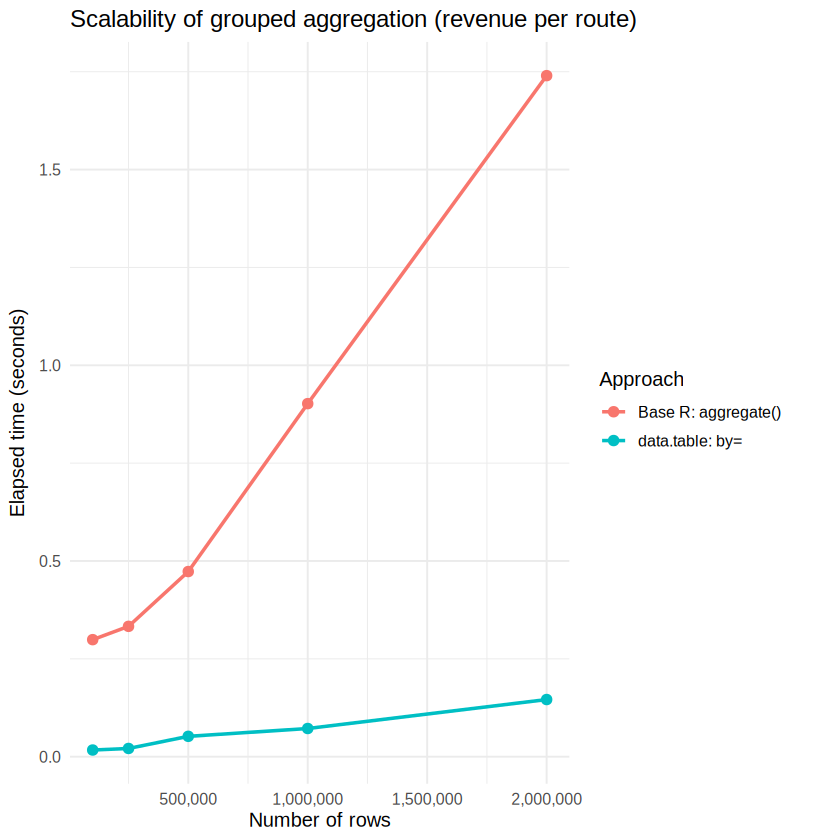

In [80]:
sizes <- c(1e5, 2.5e5, 5e5, 1e6, 2e6); sizes <- sizes[sizes <= nrow(taxi)]
scal_group <- rbindlist(lapply(sizes, function(n) {
  d <- taxi[sample(.N, n), .(total_amount, PULocationID, DOLocationID)]; df <- as.data.frame(d)
  data.table(rows = n,
    `Base R: aggregate()` = system.time(aggregate(total_amount ~ PULocationID + DOLocationID, df, sum))[["elapsed"]],
    `data.table: by=`     = system.time(d[, .(sum(total_amount)), by = .(PULocationID, DOLocationID)])[["elapsed"]])
}))
scal_group
sg <- melt(scal_group, id.vars = "rows", variable.name = "Approach", value.name = "seconds")
ggplot(sg, aes(rows, seconds, colour = Approach)) + geom_line(linewidth = 1) + geom_point(size = 2.5) +
  scale_x_continuous(labels = comma) +
  labs(title = "Scalability of grouped aggregation (revenue per route)",
       x = "Number of rows", y = "Elapsed time (seconds)", colour = "Approach")

rows,Functional: apply(),Functional: purrr::map2_dbl(),Vectorized: a / b,data.table: j expression
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1e+04,0.091,0.033,0.001,0.002
2e+04,0.106,0.036,0.000,0.002
5e+04,0.277,0.093,0.000,0.002
1e+05,0.652,0.189,0.000,0.005
2e+05,2.125,0.420,0.001,0.004


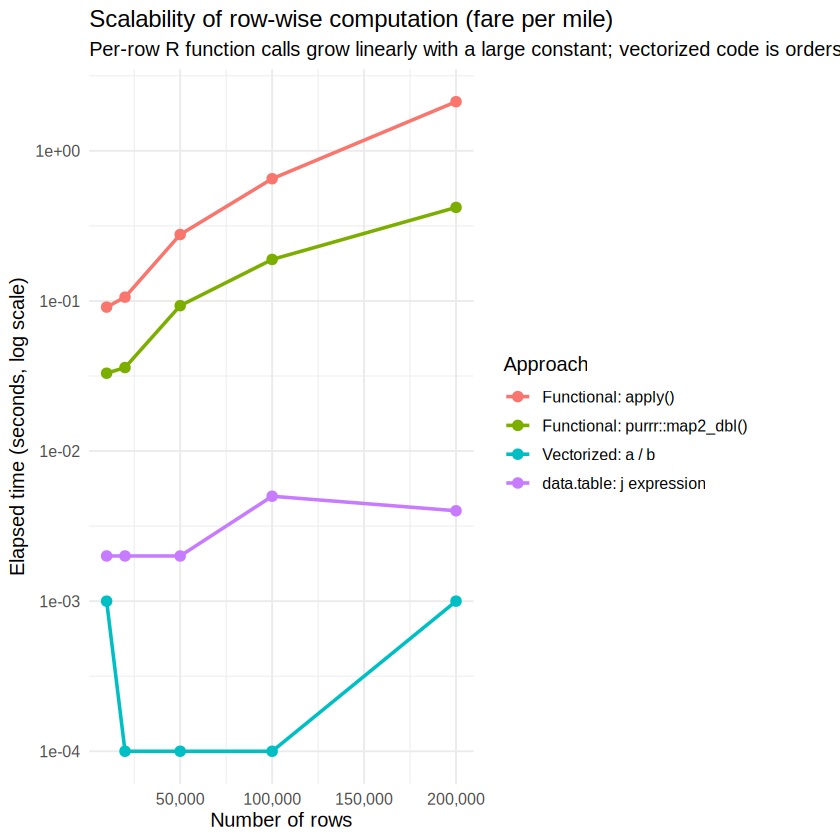

In [81]:
sizes_rw <- c(1e4, 2e4, 5e4, 1e5, 2e5)
scal_row <- rbindlist(lapply(sizes_rw, function(n) {
  d <- taxi[sample(.N, n), .(fare_amount, trip_distance)]; m <- as.matrix(d); df <- as.data.frame(d)
  data.table(rows = n,
    `Functional: apply()`           = system.time(apply(m, 1, function(r) r[1] / r[2]))[["elapsed"]],
    `Functional: purrr::map2_dbl()` = system.time(purrr::map2_dbl(df$fare_amount, df$trip_distance, ~ .x / .y))[["elapsed"]],
    `Vectorized: a / b`             = system.time(df$fare_amount / df$trip_distance)[["elapsed"]],
    `data.table: j expression`      = system.time(d[, .(fare_amount / trip_distance)])[["elapsed"]])
}))
scal_row
sr <- melt(scal_row, id.vars = "rows", variable.name = "Approach", value.name = "seconds")
ggplot(sr, aes(rows, pmax(seconds, 1e-4), colour = Approach)) + geom_line(linewidth = 1) + geom_point(size = 2.5) +
  scale_x_continuous(labels = comma) + scale_y_log10() +
  labs(title = "Scalability of row-wise computation (fare per mile)",
       subtitle = "Per-row R function calls grow linearly with a large constant; vectorized code is orders of magnitude faster",
       x = "Number of rows", y = "Elapsed time (seconds, log scale)", colour = "Approach")

## Task 6: Data Visualization (ggplot2)
Each plot is followed by a short interpretation computed from the data.

### Number of trips by hour

Interpretation: demand is lowest around 04:00, climbs through the morning and peaks at 18:00 (845,559 trips), consistent with the evening commute and nightlife.


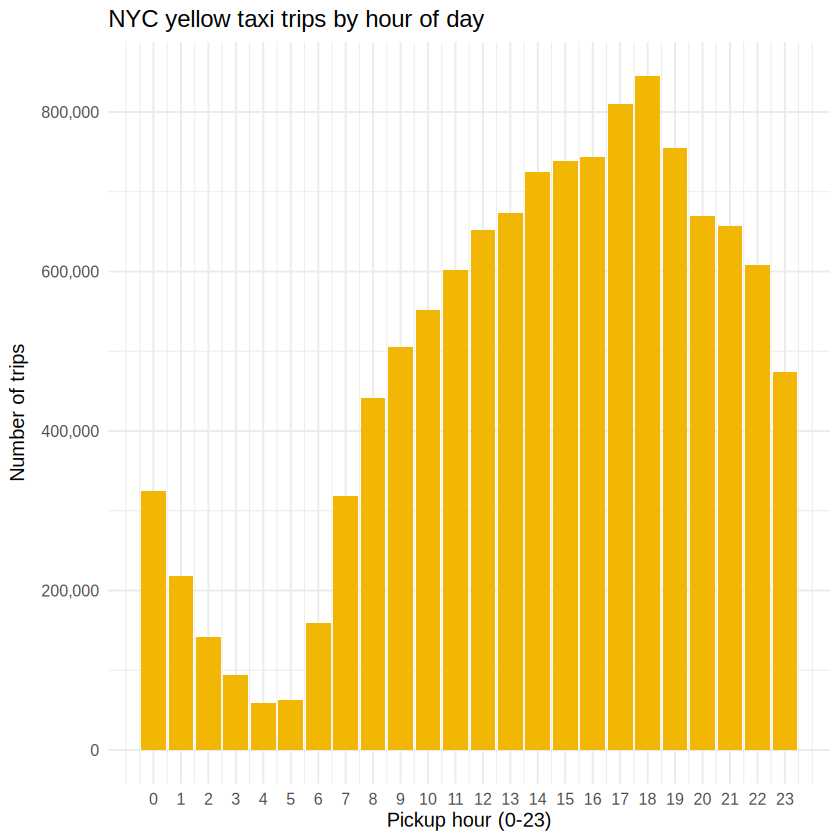

In [82]:
ggplot(hourly, aes(hour, trips)) +
  geom_col(fill = "#F2B705") +
  scale_x_continuous(breaks = 0:23) + scale_y_continuous(labels = comma) +
  labs(title = "NYC yellow taxi trips by hour of day", x = "Pickup hour (0-23)", y = "Number of trips")
cat(sprintf("Interpretation: demand is lowest around %02d:00, climbs through the morning and peaks at %02d:00 (%s trips), consistent with the evening commute and nightlife.\n",
            hourly[which.min(trips), hour], hourly[which.max(trips), hour], comma(max(hourly$trips))))

### Demand by day of week

Interpretation: Thu is the busiest day and Mon the quietest; weekday demand is driven by commuting/business travel.


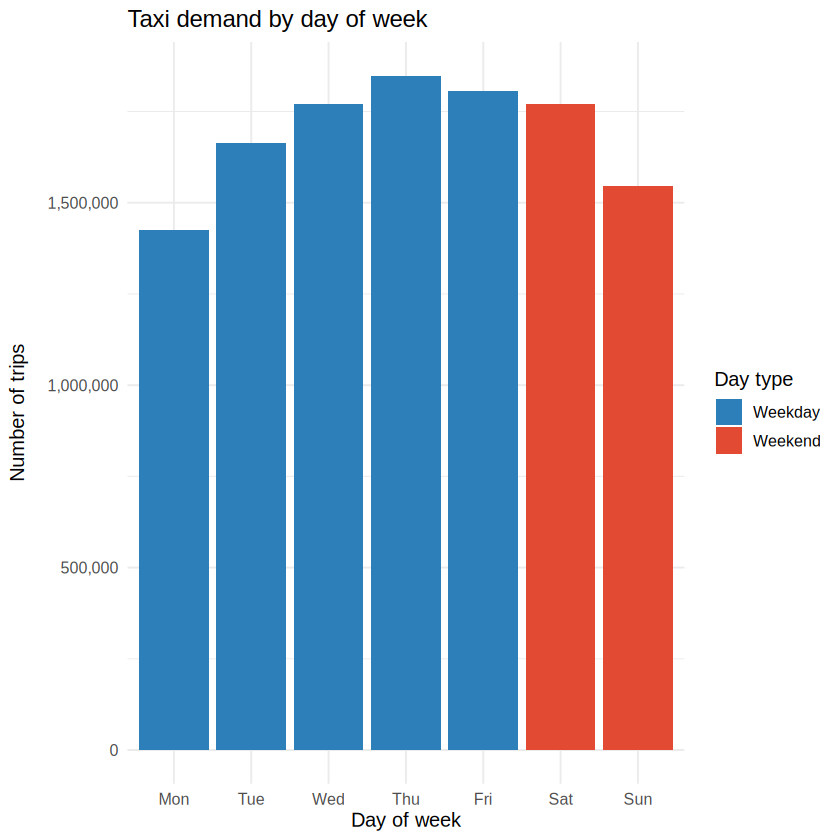

In [83]:
ggplot(daily, aes(dow, trips, fill = dow %in% c("Sat", "Sun"))) +
  geom_col(show.legend = TRUE) +
  scale_fill_manual(values = c("FALSE" = "#2C7FB8", "TRUE" = "#E34A33"), labels = c("Weekday", "Weekend")) +
  scale_y_continuous(labels = comma) +
  labs(title = "Taxi demand by day of week", x = "Day of week", y = "Number of trips", fill = "Day type")
cat(sprintf("Interpretation: %s is the busiest day and %s the quietest; weekday demand is driven by commuting/business travel.\n",
            daily[which.max(trips), dow], daily[which.min(trips), dow]))

### Monthly taxi demand and average fare

Interpretation: Mar has the highest demand; short months and winter weather depress trip counts.


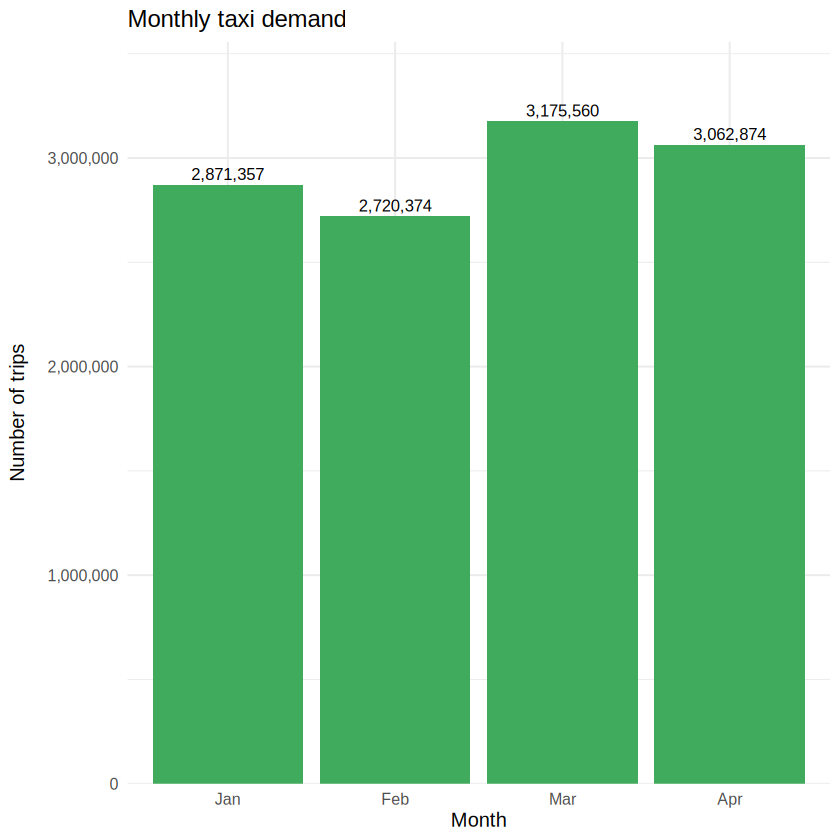

In [84]:
ggplot(monthly, aes(month_lab, trips)) +
  geom_col(fill = "#41AB5D") +
  geom_text(aes(label = comma(trips)), vjust = -0.4, size = 3.5) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, .12))) +
  labs(title = "Monthly taxi demand", x = "Month", y = "Number of trips")
cat(sprintf("Interpretation: %s has the highest demand; short months and winter weather depress trip counts.\n", monthly[which.max(trips), month_lab]))

### Average fare trends (hour of day, weekday vs weekend)

Interpretation: the highest average fare occurs at 05:00 (about $28.97), typically early-morning airport runs; average fares dip during congested daytime hours when trips are short.


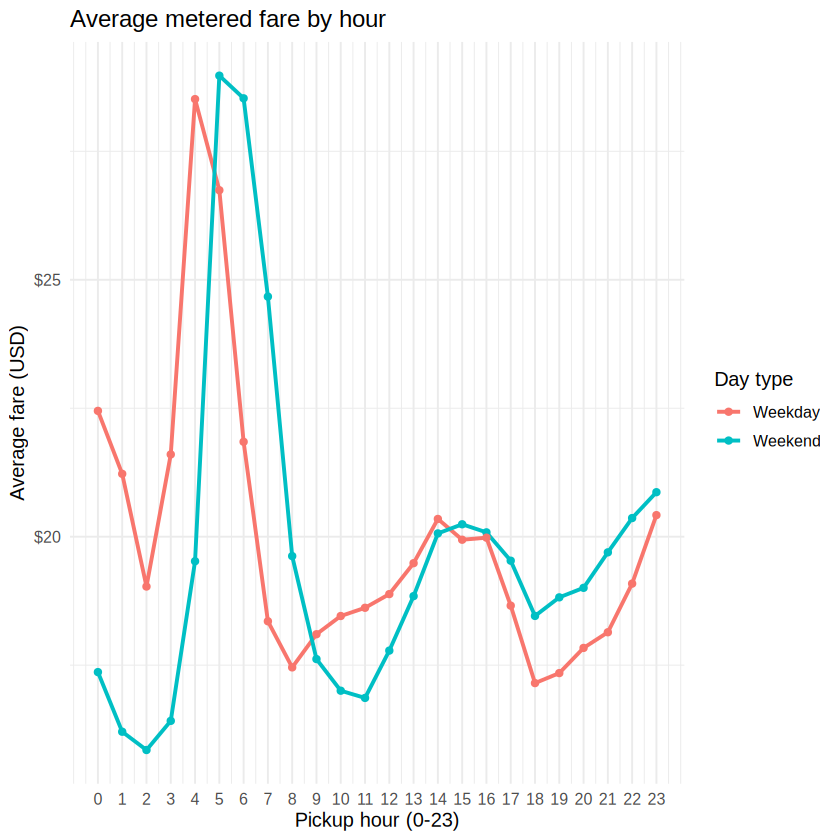

In [85]:
fare_trend <- taxi[, .(avg_fare = mean(fare_amount)), by = .(hour, day_type = ifelse(weekend, "Weekend", "Weekday"))]
ggplot(fare_trend, aes(hour, avg_fare, colour = day_type)) +
  geom_line(linewidth = 1.1) + geom_point() +
  scale_x_continuous(breaks = 0:23) + scale_y_continuous(labels = dollar) +
  labs(title = "Average metered fare by hour", x = "Pickup hour (0-23)", y = "Average fare (USD)", colour = "Day type")
cat(sprintf("Interpretation: the highest average fare occurs at %02d:00 (about $%.2f), typically early-morning airport runs; average fares dip during congested daytime hours when trips are short.\n",
            fare_trend[which.max(avg_fare), hour], max(fare_trend$avg_fare)))

### Revenue trend over time

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


Interpretation: daily revenue ranges from $1.93M to $3.50M; the weekly saw-tooth reflects weekday/weekend demand and dips mark holidays or storms.


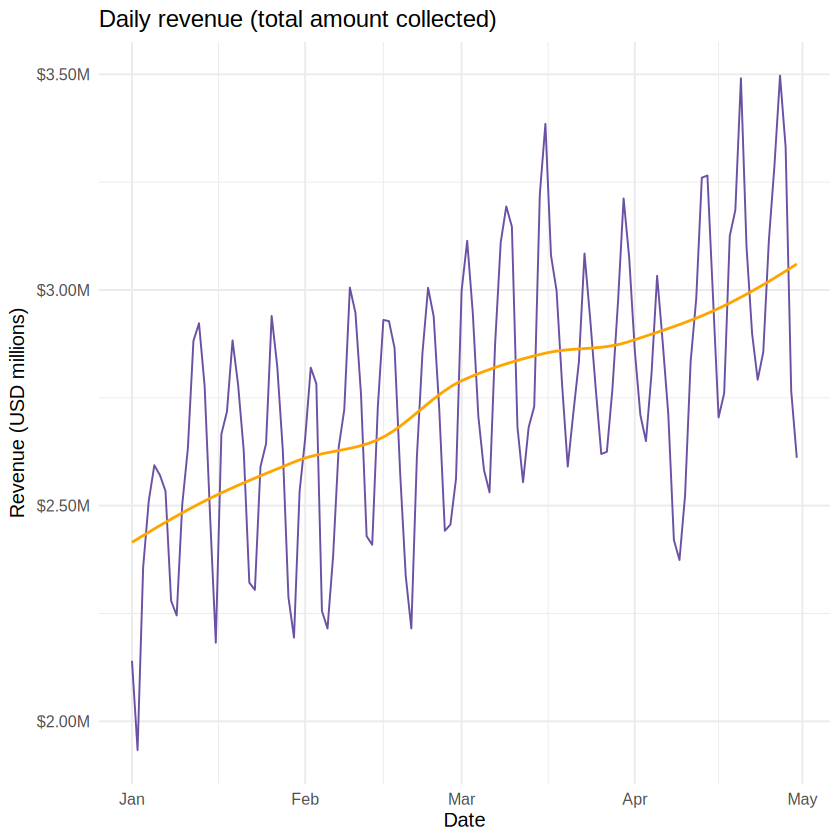

In [86]:
rev_day <- taxi[, .(revenue = sum(total_amount)), by = .(date = lubridate::as_date(pickup))][order(date)]
ggplot(rev_day, aes(date, revenue)) +
  geom_line(colour = "#6A51A3") + geom_smooth(se = FALSE, colour = "orange", linewidth = 0.8) +
  scale_y_continuous(labels = label_dollar(scale = 1e-6, suffix = "M")) +
  labs(title = "Daily revenue (total amount collected)", x = "Date", y = "Revenue (USD millions)")
cat(sprintf("Interpretation: daily revenue ranges from $%.2fM to $%.2fM; the weekly saw-tooth reflects weekday/weekend demand and dips mark holidays or storms.\n",
            min(rev_day$revenue) / 1e6, max(rev_day$revenue) / 1e6))

### Top pickup and drop-off locations

Interpretation: JFK Airport is the top pickup zone (597,944 trips); Manhattan and the airports dominate pickups.


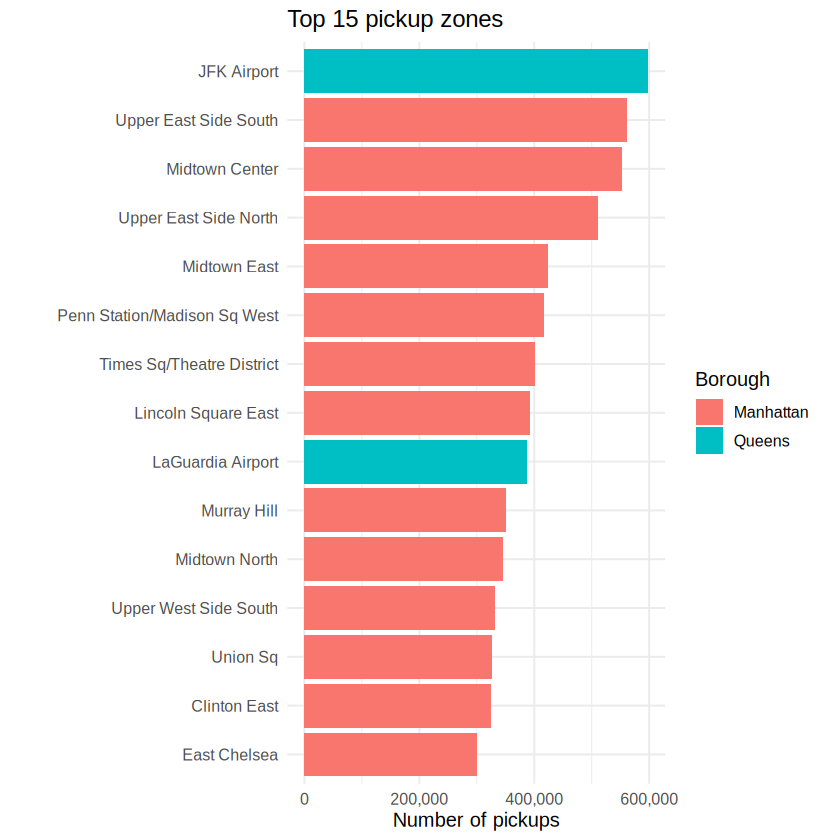

In [87]:
plot_top_zones <- function(dt, zone_col, borough_col, title, xlab) {
  d <- dt[1:15]; d[, z := factor(get(zone_col), levels = rev(get(zone_col)))]
  ggplot(d, aes(z, trips, fill = get(borough_col))) + geom_col() + coord_flip() +
    scale_y_continuous(labels = comma) + labs(title = title, x = NULL, y = xlab, fill = "Borough")
}
plot_top_zones(top_pu, "PU_Zone", "PU_Borough", "Top 15 pickup zones", "Number of pickups")
cat(sprintf("Interpretation: %s is the top pickup zone (%s trips); Manhattan and the airports dominate pickups.\n", top_pu$PU_Zone[1], comma(top_pu$trips[1])))

Interpretation: Upper East Side North is the top drop-off zone (541,847 trips); drop-offs are more spread out than pickups because residential areas in other boroughs also appear.


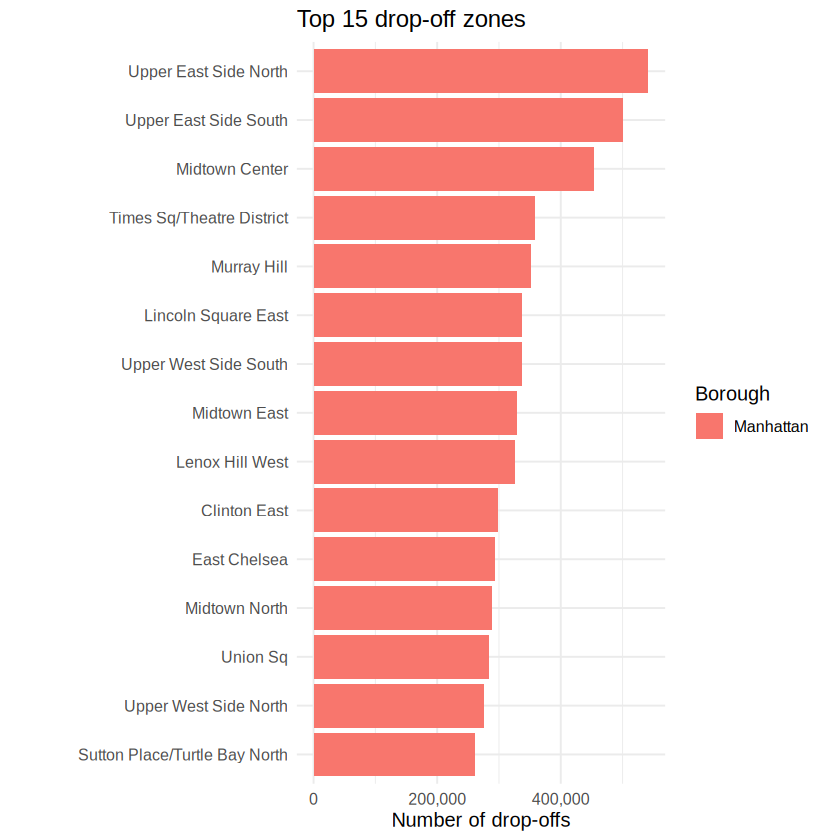

In [88]:
plot_top_zones(top_do, "DO_Zone", "DO_Borough", "Top 15 drop-off zones", "Number of drop-offs")
cat(sprintf("Interpretation: %s is the top drop-off zone (%s trips); drop-offs are more spread out than pickups because residential areas in other boroughs also appear.\n", top_do$DO_Zone[1], comma(top_do$trips[1])))

### Most frequent and highest-revenue routes

Interpretation: short intra-Manhattan hops (and same-zone trips) dominate the most frequent routes (top: Upper East Side South -> Upper East Side North).


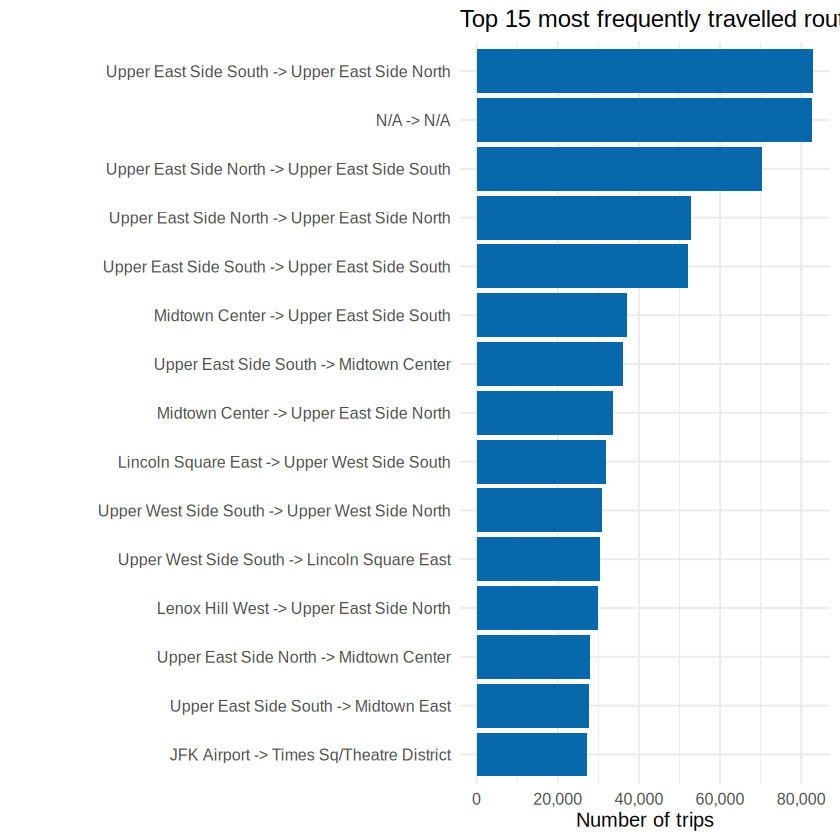

In [89]:
ggplot(top_routes_freq[order(trips)][, route := factor(route, levels = route)], aes(route, trips)) +
  geom_col(fill = "#0868AC") + coord_flip() + scale_y_continuous(labels = comma) +
  labs(title = "Top 15 most frequently travelled routes", x = NULL, y = "Number of trips")
cat(sprintf("Interpretation: short intra-Manhattan hops (and same-zone trips) dominate the most frequent routes (top: %s).\n", top_routes_freq$route[1]))

Interpretation: airport routes (e.g. JFK Airport -> Times Sq/Theatre District) earn the most per trip, so they rank highly in revenue even with fewer trips than short Manhattan hops.


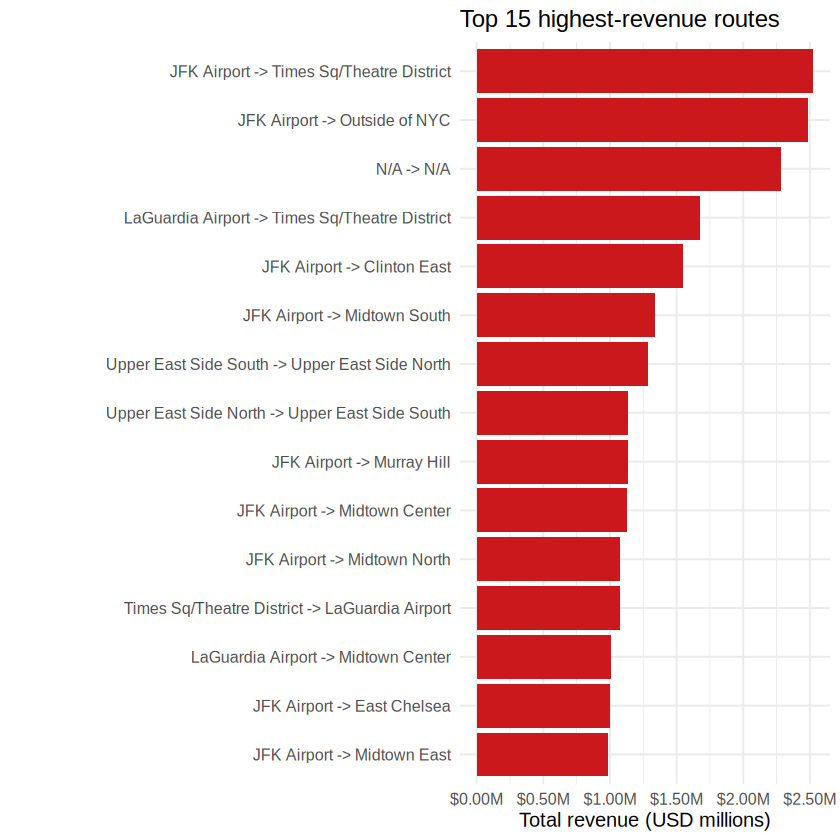

In [90]:
ggplot(top_routes_rev[order(revenue)][, route := factor(route, levels = route)], aes(route, revenue)) +
  geom_col(fill = "#CB181D") + coord_flip() + scale_y_continuous(labels = label_dollar(scale = 1e-6, suffix = "M")) +
  labs(title = "Top 15 highest-revenue routes", x = NULL, y = "Total revenue (USD millions)")
cat(sprintf("Interpretation: airport routes (e.g. %s) earn the most per trip, so they rank highly in revenue even with fewer trips than short Manhattan hops.\n", top_routes_rev$route[1]))

### Payment-type distribution

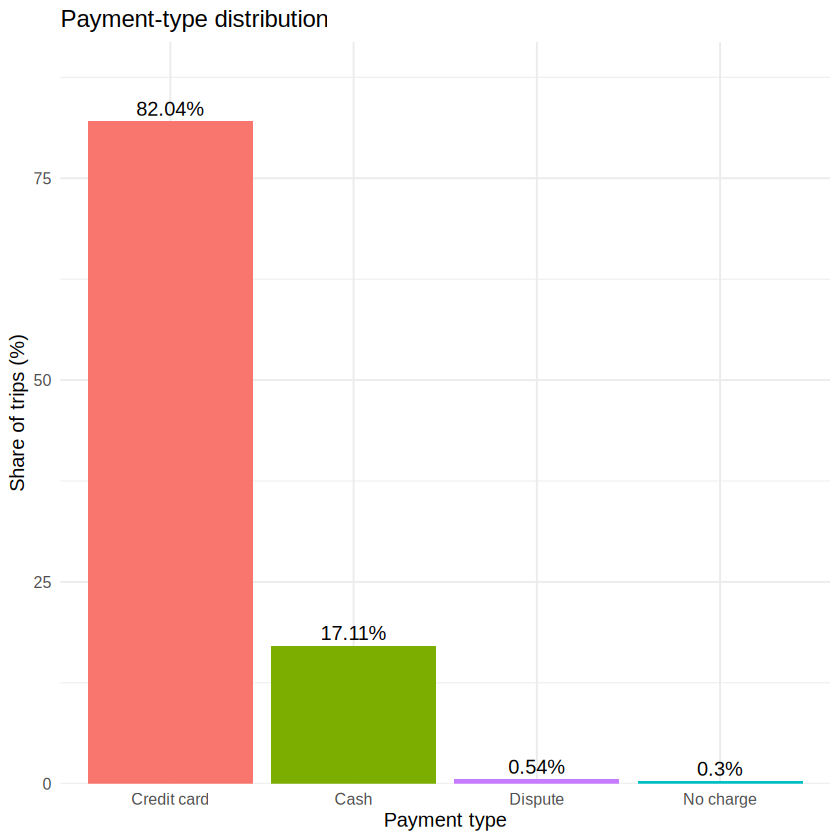

Interpretation: Credit card accounts for 82.0% of trips; cash use is higher in the outer boroughs than in Manhattan.


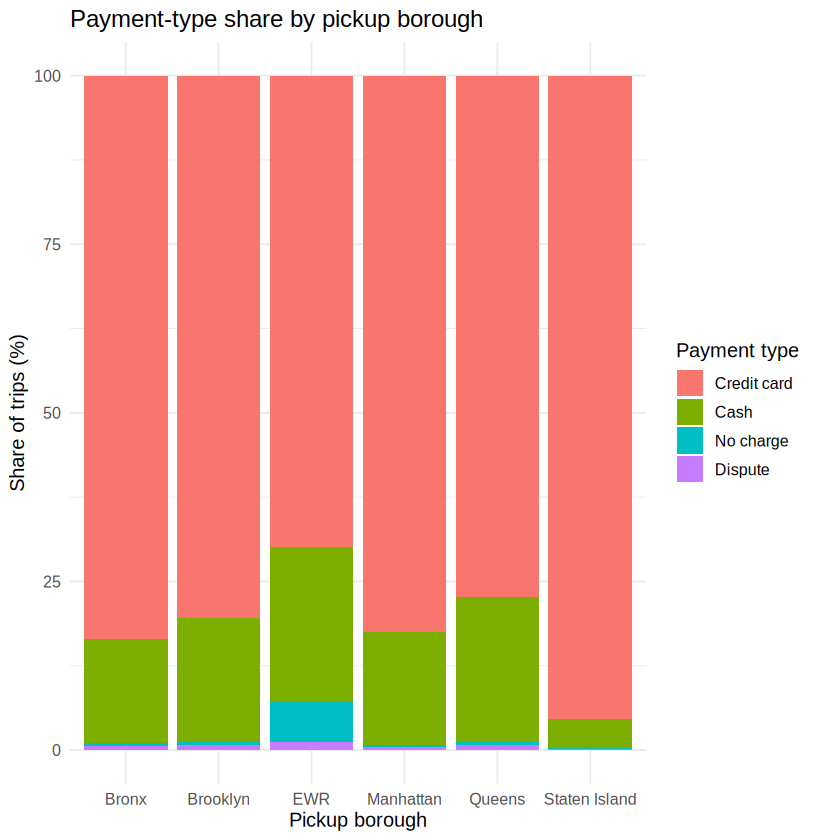

In [91]:
ggplot(pay_overall, aes(reorder(payment_type, -trips), share_pct, fill = payment_type)) +
  geom_col(show.legend = FALSE) + geom_text(aes(label = paste0(share_pct, "%")), vjust = -0.4) +
  labs(title = "Payment-type distribution", x = "Payment type", y = "Share of trips (%)") +
  scale_y_continuous(expand = expansion(mult = c(0, .12)))
pb <- pay_borough[PU_Borough %in% c("Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island", "EWR")]
ggplot(pb, aes(PU_Borough, share_pct, fill = payment_type)) + geom_col() +
  labs(title = "Payment-type share by pickup borough", x = "Pickup borough", y = "Share of trips (%)", fill = "Payment type")
cat(sprintf("Interpretation: %s accounts for %.1f%% of trips; cash use is higher in the outer boroughs than in Manhattan.\n", pay_overall$payment_type[1], pay_overall$share_pct[1]))

### Trip distance vs fare amount

`geom_smooth()` using formula = 'y ~ x'


Interpretation: strong positive linear relationship (r = 0.96); the horizontal cluster near $70 is the flat JFK fare and the red line shows ~$3.70 per mile.


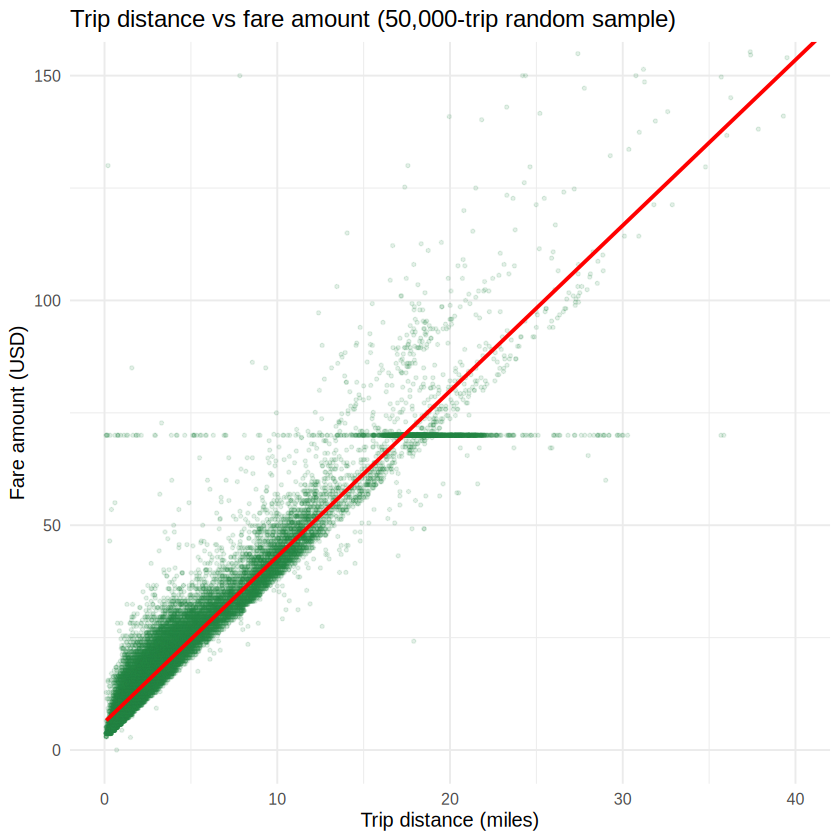

In [92]:
sc <- taxi[sample(.N, 50000)]
ggplot(sc, aes(trip_distance, fare_amount)) +
  geom_point(alpha = 0.12, colour = "#238B45", size = 0.8) +
  geom_smooth(method = "lm", colour = "red", se = FALSE) +
  coord_cartesian(xlim = c(0, 40), ylim = c(0, 150)) +
  labs(title = "Trip distance vs fare amount (50,000-trip random sample)",
       x = "Trip distance (miles)", y = "Fare amount (USD)")
cat(sprintf("Interpretation: strong positive linear relationship (r = %.2f); the horizontal cluster near $70 is the flat JFK fare and the red line shows ~$%.2f per mile.\n",
            cor(taxi$trip_distance, taxi$fare_amount), coef(fit)[2]))

### Heat-map (hour × weekday)

Interpretation: weekday evening rush hours are hot-spots while weekend nights shift later (nightlife); early-morning hours are cold on all days.


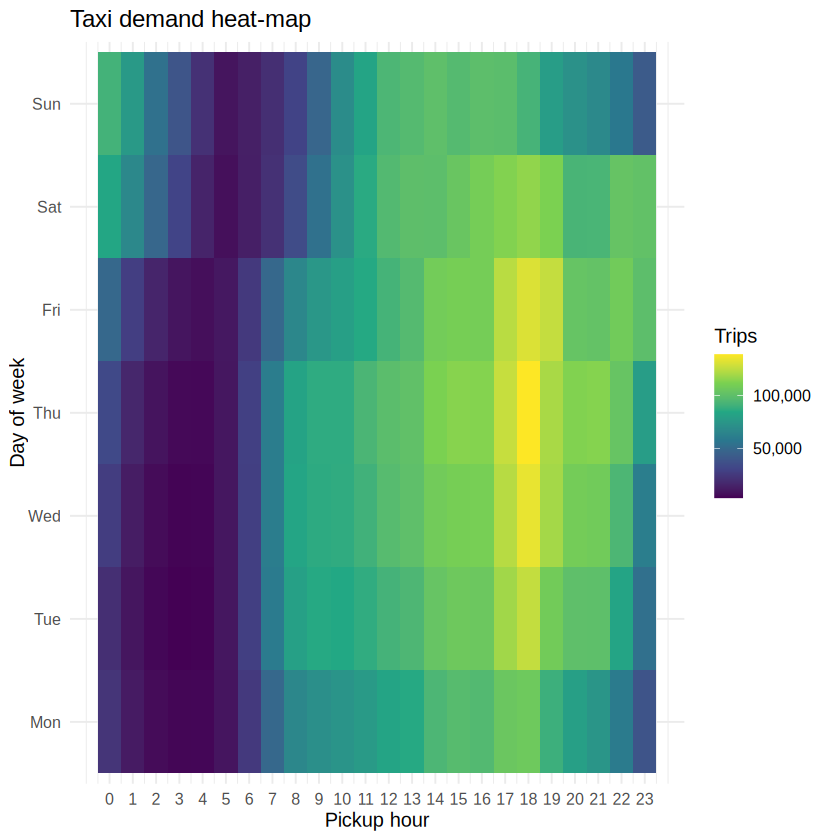

In [93]:
heat <- taxi[, .N, by = .(hour, dow)]
ggplot(heat, aes(hour, dow, fill = N)) + geom_tile() +
  scale_fill_viridis_c(labels = comma) + scale_x_continuous(breaks = 0:23) +
  labs(title = "Taxi demand heat-map", x = "Pickup hour", y = "Day of week", fill = "Trips")
cat("Interpretation: weekday evening rush hours are hot-spots while weekend nights shift later (nightlife); early-morning hours are cold on all days.\n")